In [1]:
import pandas as pd # handling data
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
from sklearn.preprocessing import LabelEncoder #  encode categorical value
from sklearn.model_selection import train_test_split # splitting data into training set and testing set


df=pd.read_csv('titanic.csv')


In [2]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# handling missing value
df['age'].fillna(df['age'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_16952\2172934491.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16952\2172934491.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [7]:
#drop missing value
df.drop('deck',axis=1,inplace=True)


In [8]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [9]:
# converting categorical columns
df.replace({'sex':{'male':'1','female':'0'},'embarked':{'S':'0','C':'1','Q':'3'}},inplace=True)


In [10]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,0,Third,man,True,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,1,First,woman,False,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,0,Third,woman,False,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,0,First,woman,False,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,0,Third,man,True,Southampton,no,True


In [11]:
# encode categorical value
le=LabelEncoder()
df['alive_encoder']=le.fit_transform(df['alive'])
df['alone_encoder']=le.fit_transform(df['alone'])

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,alive_encoder,alone_encoder
0,0,3,1,22.0,1,0,7.2500,0,Third,man,True,Southampton,no,False,0,0
1,1,1,0,38.0,1,0,71.2833,1,First,woman,False,Cherbourg,yes,False,1,0
2,1,3,0,26.0,0,0,7.9250,0,Third,woman,False,Southampton,yes,True,1,1
3,1,1,0,35.0,1,0,53.1000,0,First,woman,False,Southampton,yes,False,1,0
4,0,3,1,35.0,0,0,8.0500,0,Third,man,True,Southampton,no,True,0,1


In [13]:
# splitting data into training set and testing set
x=df.drop(columns=['survived','who'],axis=1)
y=df['survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

print(x.shape,x_train.shape,x_test.shape)

(891, 14) (712, 14) (179, 14)


In [14]:
print(x_train)


     pclass sex   age  sibsp  parch     fare embarked  class  adult_male  \
16        3   1   2.0      4      1  29.1250        3  Third       False   
352       3   1  15.0      1      1   7.2292        1  Third       False   
725       3   1  20.0      0      0   8.6625        0  Third        True   
157       3   1  30.0      0      0   8.0500        0  Third        True   
556       1   0  48.0      1      0  39.6000        1  First       False   
..      ...  ..   ...    ...    ...      ...      ...    ...         ...   
575       3   1  19.0      0      0  14.5000        0  Third        True   
266       3   1  16.0      4      1  39.6875        0  Third        True   
350       3   1  23.0      0      0   9.2250        0  Third        True   
197       3   1  42.0      0      1   8.4042        0  Third        True   
838       3   1  32.0      0      0  56.4958        0  Third        True   

     embark_town alive  alone  alive_encoder  alone_encoder  
16    Queenstown    no  F

In [15]:
print(x_test)

     pclass sex   age  sibsp  parch      fare embarked   class  adult_male  \
822       1   1  38.0      0      0    0.0000        0   First        True   
297       1   0   2.0      1      2  151.5500        0   First       False   
300       3   0  28.0      0      0    7.7500        3   Third       False   
66        2   0  29.0      0      0   10.5000        0  Second       False   
246       3   0  25.0      0      0    7.7750        0   Third       False   
..      ...  ..   ...    ...    ...       ...      ...     ...         ...   
563       3   1  28.0      0      0    8.0500        0   Third        True   
722       2   1  34.0      0      0   13.0000        0  Second        True   
847       3   1  35.0      0      0    7.8958        1   Third        True   
135       2   1  23.0      0      0   15.0458        1  Second        True   
112       3   1  22.0      0      0    8.0500        0   Third        True   

     embark_town alive  alone  alive_encoder  alone_encoder  
8

In [16]:
print(y_train)

16     0
352    0
725    0
157    0
556    1
      ..
575    0
266    0
350    0
197    0
838    1
Name: survived, Length: 712, dtype: int64


In [17]:
print(y_test)

822    0
297    0
300    1
66     1
246    0
      ..
563    0
722    0
847    0
135    0
112    0
Name: survived, Length: 179, dtype: int64


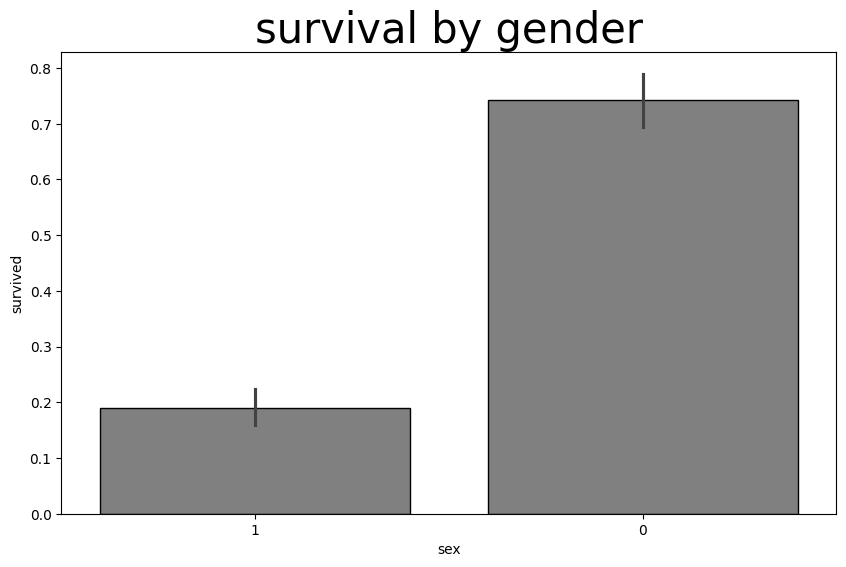

In [18]:
# data visualization
plt.figure(figsize=(10,6))
sns.barplot(x='sex',y='survived',data=df,color='grey',edgecolor='black')
plt.title('survival by gender',size=30)
plt.show()

Text(0.5, 1.0, 'passenger age distribution')

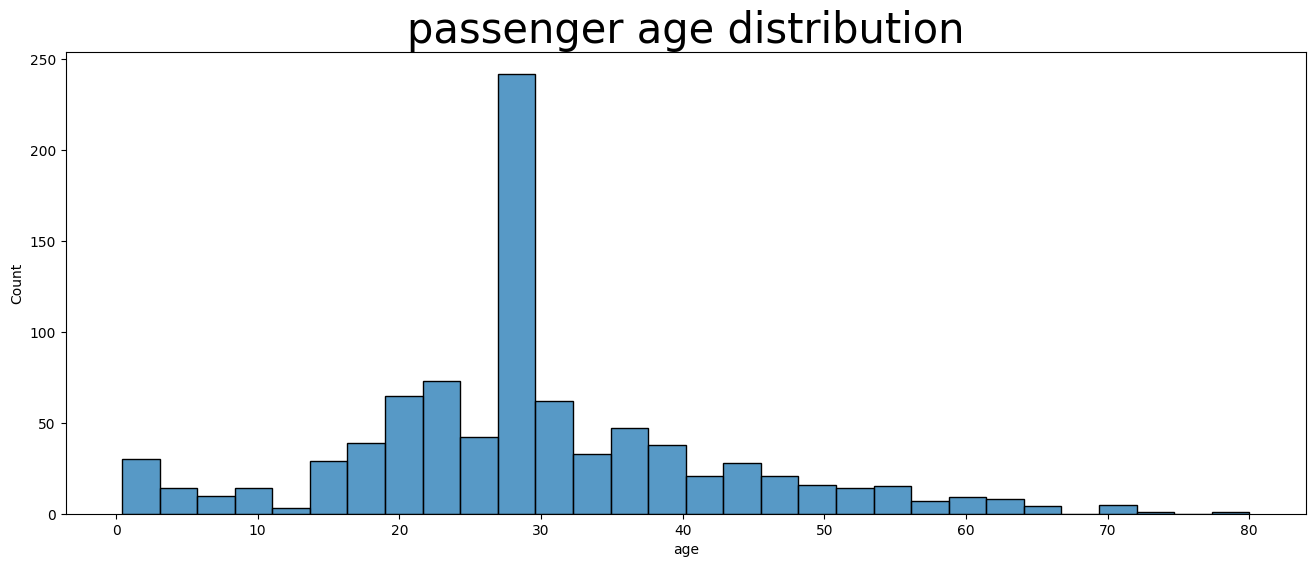

In [19]:
plt.figure(figsize=(16,6))
sns.histplot(df['age'])
plt.title('passenger age distribution',size=30)

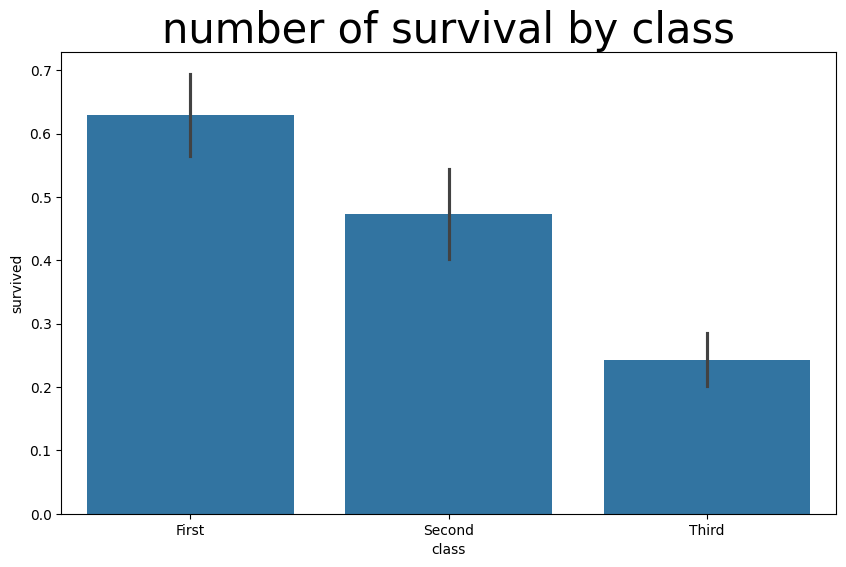

In [20]:
order1=['First','Second','Third']
plt.figure(figsize=(10,6))
sns.barplot(x='class',y='survived',data=df,order=order1)
plt.title('number of survival by class',size=30)
plt.show()

